In [105]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [106]:
df = pd.read_csv('../data/processed/german_credit_encoded.csv')

In [107]:
X = df.drop(['class', 'credit_history_critical/other existing credit', 'checking_status_no checking', 'checking_status_<0'], axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Задач для обучения: {len(X_train)}")
print(f"Задач для экзамена: {len(X_test)}")

Задач для обучения: 700
Задач для экзамена: 300


In [108]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

display(X_train_scaled.head())

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_>=200,credit_history_delayed previously,credit_history_existing paid,...,property_magnitude_real estate,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_yes,foreign_worker_yes
0,0.231016,-0.462936,0.911164,1.057385,2.179382,0.997799,-0.398673,-0.258985,3.125577,-1.020204,...,-0.625820,0.466252,-0.200297,-1.592279,-0.459426,0.766356,-0.147979,-0.475310,1.164862,0.200297
1,-0.778104,-0.512772,0.911164,1.057385,0.311885,-0.722544,-0.398673,-0.258985,-0.319941,0.980196,...,-0.625820,0.466252,-0.200297,0.628031,-0.459426,-1.304877,-0.147979,-0.475310,1.164862,0.200297
2,0.735576,0.072458,0.911164,1.057385,1.912597,0.997799,-0.398673,-0.258985,-0.319941,0.980196,...,-0.625820,0.466252,-0.200297,-1.592279,2.176627,0.766356,-0.147979,-0.475310,1.164862,0.200297
3,-0.778104,-0.824580,-0.877938,0.150315,1.023312,0.997799,2.508319,-0.258985,-0.319941,-1.020204,...,1.597905,0.466252,-0.200297,0.628031,-0.459426,-1.304877,-0.147979,2.103891,-0.858471,0.200297
4,1.240136,0.775879,0.911164,-0.756756,0.222956,0.997799,-0.398673,-0.258985,-0.319941,-1.020204,...,-0.625820,0.466252,-0.200297,0.628031,-0.459426,-1.304877,-0.147979,-0.475310,1.164862,0.200297


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [110]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность (Accuracy) на экзамене: {accuracy * 100:.2f}%")

Точность (Accuracy) на экзамене: 73.33%


In [111]:
from sklearn.metrics import confusion_matrix, classification_report

In [112]:
cm = confusion_matrix(y_test, y_pred)
print("Матрица путаницы:")
print(cm)

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred))

Матрица путаницы:
[[ 36  55]
 [ 25 184]]

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.59      0.40      0.47        91
           1       0.77      0.88      0.82       209

    accuracy                           0.73       300
   macro avg       0.68      0.64      0.65       300
weighted avg       0.72      0.73      0.72       300



In [113]:
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Матрица путаницы (с балансировкой):")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nОтчет о классификации модели с балансировкой:")
print(classification_report(y_test, y_pred_balanced))

Матрица путаницы (с балансировкой):
[[ 63  28]
 [ 67 142]]

Отчет о классификации модели с балансировкой:
              precision    recall  f1-score   support

           0       0.48      0.69      0.57        91
           1       0.84      0.68      0.75       209

    accuracy                           0.68       300
   macro avg       0.66      0.69      0.66       300
weighted avg       0.73      0.68      0.69       300



In [114]:
y_probs = model_balanced.predict_proba(X_test_scaled)[:, 1]

custom_threshold = 0.70
y_pred_strict = (y_probs > custom_threshold).astype(int)

print(f"Матрица при пороге {custom_threshold}:")
print(confusion_matrix(y_test, y_pred_strict))
print("\nОтчет:")
print(classification_report(y_test, y_pred_strict))

Матрица при пороге 0.7:
[[ 78  13]
 [124  85]]

Отчет:
              precision    recall  f1-score   support

           0       0.39      0.86      0.53        91
           1       0.87      0.41      0.55       209

    accuracy                           0.54       300
   macro avg       0.63      0.63      0.54       300
weighted avg       0.72      0.54      0.55       300



In [115]:
importance = model_balanced.coef_[0]
feature_names = X.columns

feature_importance = pd.DataFrame({'feature':feature_names, 'importance':importance})

feature_importance['abs_importance'] = feature_importance['importance'].abs()
feature_importance = feature_importance.sort_values(by='abs_importance', ascending=False)

print("Топ 10 самых влиятльных признаков")
display(feature_importance.head(10))

Топ 10 самых влиятльных признаков


,feature,importance,abs_importance
4,age,0.375480,0.375480
19,purpose_used car,0.349460,0.349460
10,credit_history_no credits/all paid,-0.328153,0.328153
2,installment_commitment,-0.320273,0.320273
9,credit_history_existing paid,-0.319148,0.319148
0,duration,-0.313523,0.313523
1,credit_amount,-0.303780,0.303780
44,foreign_worker_yes,-0.295556,0.295556
14,purpose_new car,-0.258827,0.258827
16,purpose_radio/tv,0.256207,0.256207


In [116]:
from sklearn.ensemble import RandomForestClassifier

In [117]:
model_rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')

model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Матрица путаницы (Случайный лес):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nОтчет о классификации (Случайный лес):")
print(classification_report(y_test, y_pred_rf))


Матрица путаницы (Случайный лес):
[[ 23  68]
 [  7 202]]

Отчет о классификации (Случайный лес):
              precision    recall  f1-score   support

           0       0.77      0.25      0.38        91
           1       0.75      0.97      0.84       209

    accuracy                           0.75       300
   macro avg       0.76      0.61      0.61       300
weighted avg       0.75      0.75      0.70       300



In [118]:
rf_importance = model_rf.feature_importances_

rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importance
})

rf_feature_importance = rf_feature_importance.sort_values(by='importance', ascending=False)

display(rf_feature_importance.head(10))

,feature,importance
1,credit_amount,0.127885
4,age,0.111646
0,duration,0.095778
3,residence_since,0.044534
2,installment_commitment,0.044506
5,existing_credits,0.027014
14,purpose_new car,0.026346
21,savings_status_<100,0.026190
43,own_telephone_yes,0.025649
30,personal_status_male single,0.023101


In [119]:
rf_probs = model_rf.predict_proba(X_test_scaled)[:, 1]

rf_threshold = 0.7
y_pred_rf_strict = (rf_probs > rf_threshold).astype(int)

print(f"Матрица путаницы (Лес с порогом {rf_threshold}):")
print(confusion_matrix(y_test, y_pred_rf_strict))

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_rf_strict))

Матрица путаницы (Лес с порогом 0.7):
[[ 58  33]
 [ 65 144]]

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.47      0.64      0.54        91
           1       0.81      0.69      0.75       209

    accuracy                           0.67       300
   macro avg       0.64      0.66      0.64       300
weighted avg       0.71      0.67      0.68       300



In [120]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test_scaled)

print("\nМатрица путаницы (Оптимизированный Лес):")
print(confusion_matrix(y_test, y_pred_best))

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_best))


Матрица путаницы (Оптимизированный Лес):
[[ 43  48]
 [ 49 160]]

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        91
           1       0.77      0.77      0.77       209

    accuracy                           0.68       300
   macro avg       0.62      0.62      0.62       300
weighted avg       0.68      0.68      0.68       300



In [121]:
y_prob_pred_rf = best_rf_model.predict_proba(X_test_scaled)[:,1]

rf_threshold = 0.55
y_best_pred_rf_strict = (y_prob_pred_rf > rf_threshold).astype(int)

print("Матрица путаницы (Лучший из ансамбля лесов, с ограничением)")
print(confusion_matrix(y_test, y_best_pred_rf_strict))

print("\nОтчет о классификации")
print(classification_report(y_test, y_best_pred_rf_strict))

Матрица путаницы (Лучший из ансамбля лесов, с ограничением)
[[ 66  25]
 [ 85 124]]

Отчет о классификации
              precision    recall  f1-score   support

           0       0.44      0.73      0.55        91
           1       0.83      0.59      0.69       209

    accuracy                           0.63       300
   macro avg       0.63      0.66      0.62       300
weighted avg       0.71      0.63      0.65       300



In [122]:
best_rf_importance = best_rf_model.feature_importances_

rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_importance
})

rf_feature_importance = rf_feature_importance.sort_values(by='Importance', ascending=False)

display(rf_feature_importance.head(10))

,Feature,Importance
0,duration,0.144436
1,credit_amount,0.120153
4,age,0.117871
34,property_magnitude_no known property,0.043844
38,housing_own,0.038253
10,credit_history_no credits/all paid,0.038168
2,installment_commitment,0.036469
21,savings_status_<100,0.035176
14,purpose_new car,0.033656
16,purpose_radio/tv,0.030645


In [123]:
import joblib

In [124]:
joblib.dump(best_rf_model, '../models/credit_scoring_model.pkl')
joblib.dump(scaler, '../models/standard_scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_columns.pkl')
print("Файлы сохранены в папке /models")

Файлы сохранены в папке /models


In [125]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from sklearn.pipeline import Pipeline

Графики влияния показателей на одобрение кредита


l:\Files\Various\german_credit_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
l:\Files\Various\german_credit_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
l:\Files\Various\german_credit_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
l:\Files\Various\german_credit_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
l:\Files\Various\german_credit_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does

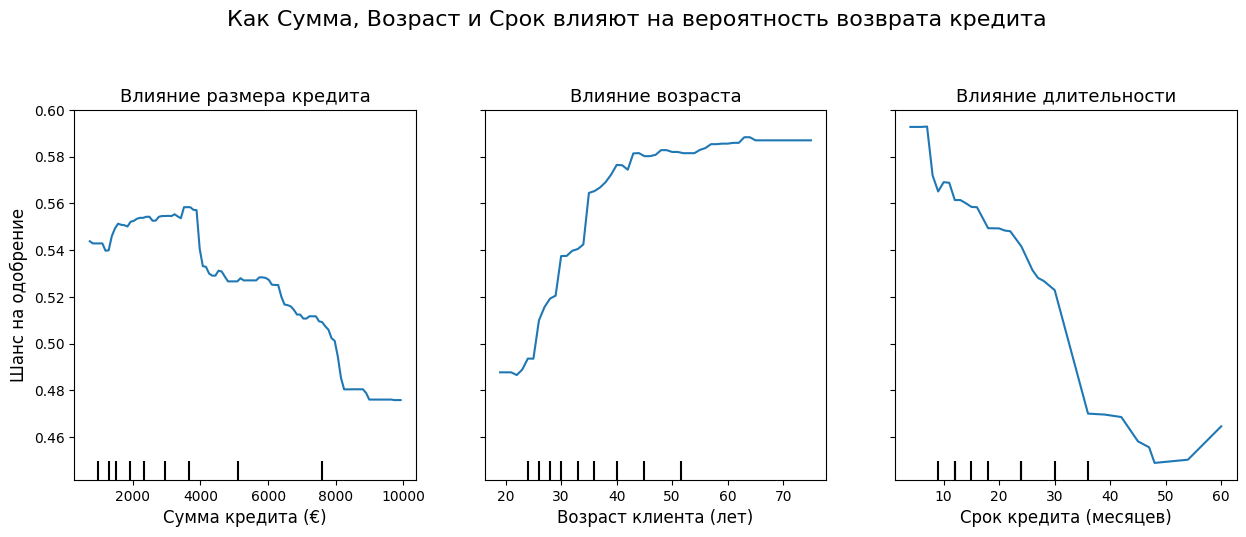

In [126]:
my_pipeline = Pipeline([
    ('scaler', scaler),
    ('rf_model', best_rf_model)
])

top_features = ['credit_amount', 'age', 'duration']

X_train_float= X_train.astype(float)

print("Графики влияния показателей на одобрение кредита")

fig, ax = plt.subplots(figsize=(15,5))

pdp_graphics = PartialDependenceDisplay.from_estimator(
    estimator=my_pipeline,
    X=X_train_float,
    features=top_features,
    feature_names=X.columns,
    target=1,
    ax=ax
)

pdp_graphics.axes_[0, 0].set_xlabel('Сумма кредита (€)', fontsize=12)
pdp_graphics.axes_[0, 0].set_ylabel('Шанс на одобрение', fontsize=12)
pdp_graphics.axes_[0, 0].set_title('Влияние размера кредита', fontsize=13)

pdp_graphics.axes_[0, 1].set_xlabel('Возраст клиента (лет)', fontsize=12)
pdp_graphics.axes_[0, 1].set_title('Влияние возраста', fontsize=13)

pdp_graphics.axes_[0, 2].set_xlabel('Срок кредита (месяцев)', fontsize=12)
pdp_graphics.axes_[0, 2].set_title('Влияние длительности', fontsize=13)

plt.suptitle('Как Сумма, Возраст и Срок влияют на вероятность возврата кредита', fontsize=16, y=1.05)
plt.subplots_adjust(top=0.85)
plt.show()